# SHAP Interpretability Analysis — All 11 Experiments

Computes SHAP values (GradientExplainer) for each subject's best model across all 11 training runs.

**Visualizations per subject per experiment:**
- Brain topography maps (MNE topomaps, divergent RdBu_r)
- Zone × Time heatmaps (brain region importance over time)
- Frequency-band importance heatmaps (Delta–Gamma)
- Zone importance bar charts
- Correct-only vs Error-only topomaps
- Electrode-level channel × time heatmaps

**Cross-experiment analyses:**
- Per-subject SHAP magnitude comparison across runs
- Class-wise spatial consistency analysis
- Global zone importance ranking across experiments

In [26]:
import os, sys, gc
import numpy as np
import pandas as pd
import torch
import h5py
import shap
import matplotlib.pyplot as plt
import matplotlib
import mne
import scipy.signal
from sklearn.metrics import accuracy_score, f1_score
from transformers import PretrainedConfig
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

sys.path.insert(0, os.path.abspath('..'))
from fast.models import FAST
from fast.data import Electrodes, Zones, SUBJECTS, CLASSES
from fast.data.loaders import load_standardized_h5

print(f'Subjects: {SUBJECTS}')
print(f'Classes: {CLASSES}')
print(f'Electrodes: {len(Electrodes)} channels')
print(f'Zones: {list(Zones.keys())}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

Subjects: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15']
Classes: ['hello', 'help-me', 'stop', 'thank-you', 'yes']
Electrodes: 64 channels
Zones: ['Pre-frontal', 'Frontal', 'Pre-central', 'Central', 'Post-central', 'Temporal', 'Parietal', 'Occipital']
Device: cuda


## 1. Configuration

In [44]:
# ============================================================
# Global configuration
# ============================================================
SEED = 42
SFREQ = 250
N_BG = 100       # Background samples for SHAP
N_EXPLAIN = 50   # Samples to explain per subject
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Condition-specific data paths (must match training conditions)
H5_ORIGINAL = '../Processed/BCIC2020Track3.h5'
H5_COND_B = '../Processed/BCIC2020Track3_ICA_no_delta.h5'
H5_COND_C = '../Processed/BCIC2020Track3_ICA_no_artifacts.h5'
H5_HP4 = '../Processed/BCIC2020Track3_highpass_4hz.h5'
H5_TEST = '../Processed/BCIC2020Track3_Test.h5'

RESULTS_BASE = '../results/condition_experiments'
SHAP_OUTPUT = '../results/shap_analysis'
os.makedirs(SHAP_OUTPUT, exist_ok=True)

MODEL_CONFIG = PretrainedConfig(
    electrodes=Electrodes, zone_dict=Zones,
    dim_cnn=32, dim_token=32, seq_len=800,
    window_len=SFREQ, slide_step=SFREQ // 2,
    head='Conv4Layers', n_classes=5,
    num_layers=4, num_heads=8, dropout=0.1,
)

# Experiment definitions: key -> (display name, results dir, model filename, data paths)
EXPERIMENTS = {
    'run1_original':       ('Run 1: Original (A)',          'run1_original',             'best_subject.pth', [H5_ORIGINAL]),
    'run2_condB':          ('Run 2: Cond B (No Delta)',     'run2_condB',                'best_subject.pth', [H5_COND_B]),
    'run3_condC':          ('Run 3: Cond C (No Artifacts)', 'run3_condC',                'best_subject.pth', [H5_COND_C]),
    'run4_A_B':            ('Run 4: A + B',                 'run4_A_B',                  'best_subject.pth', [H5_ORIGINAL, H5_COND_B]),
    'run5_A_C':            ('Run 5: A + C',                 'run5_A_C',                  'best_subject.pth', [H5_ORIGINAL, H5_COND_C]),
    'run6_A_B_C':          ('Run 6: A + B + C',             'run6_A_B_C',                'best_subject.pth', [H5_ORIGINAL, H5_COND_B, H5_COND_C]),
    'run7_B_C':            ('Run 7: B + C',                 'run7_B_C',                  'best_subject.pth', [H5_COND_B, H5_COND_C]),
    'run8_augment':        ('Run 8: Augmented + ES',        'run8_augment',              'best_subject.pth', [H5_ORIGINAL]),
    'run9_augment_no_es':  ('Run 9: Augmented No ES',       'run9_augment_no_es',        'best_subject.pth', [H5_ORIGINAL]),
    'run10_kaggle':        ('Run 10: Kaggle Replication',   'run10_kaggle_replication',  'final_model.pth',  [H5_ORIGINAL]),
    'run11_highpass4':     ('Run 11: High-pass 4 Hz',       'run11_highpass4',           'best_subject.pth', [H5_HP4]),
}

print(f'Experiments: {len(EXPERIMENTS)}')
for k, (name, d, f, h5_paths) in EXPERIMENTS.items():
    ckpt = os.path.join(RESULTS_BASE, d, 'sub-01', f)
    data_files = [os.path.basename(p) for p in h5_paths]
    print(f'  {name}: {"OK" if os.path.exists(ckpt) else "MISSING"} | data={data_files}')

Experiments: 10
  Run 1: Original (A): OK | data=['BCIC2020Track3.h5']
  Run 2: Cond B (No Delta): OK | data=['BCIC2020Track3_ICA_no_delta.h5']
  Run 3: Cond C (No Artifacts): OK | data=['BCIC2020Track3_ICA_no_artifacts.h5']
  Run 4: A + B: OK | data=['BCIC2020Track3.h5', 'BCIC2020Track3_ICA_no_delta.h5']
  Run 5: A + C: OK | data=['BCIC2020Track3.h5', 'BCIC2020Track3_ICA_no_artifacts.h5']
  Run 6: A + B + C: OK | data=['BCIC2020Track3.h5', 'BCIC2020Track3_ICA_no_delta.h5', 'BCIC2020Track3_ICA_no_artifacts.h5']
  Run 7: B + C: OK | data=['BCIC2020Track3_ICA_no_delta.h5', 'BCIC2020Track3_ICA_no_artifacts.h5']
  Run 8: Augmented + ES: OK | data=['BCIC2020Track3.h5']
  Run 9: Augmented No ES: OK | data=['BCIC2020Track3.h5']
  Run 10: Kaggle Replication: OK | data=['BCIC2020Track3.h5']


## 2. Model & Data Loading Utilities

In [45]:
def load_model(checkpoint_path, config, device):
    """Load FAST model from state_dict checkpoint."""
    model = FAST(config)
    if not os.path.exists(checkpoint_path):
        print(f'  WARNING: {checkpoint_path} not found')
        return None
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if 'state_dict' in ckpt:
        sd = {k.replace('model.', ''): v for k, v in ckpt['state_dict'].items()}
    else:
        sd = ckpt
    model.load_state_dict(sd)
    model.eval()
    model.to(device)
    return model


def load_subject_data(h5_paths, sid, n_bg=N_BG, n_explain=N_EXPLAIN):
    """Load one subject from one/multiple H5 files and split into background/explanation sets."""
    if isinstance(h5_paths, str):
        h5_paths = [h5_paths]

    X_parts, Y_parts = [], []
    for h5_path in h5_paths:
        with h5py.File(h5_path, 'r') as f:
            if sid not in f:
                continue
            X_parts.append(f[sid]['X'][()].astype(np.float32))
            Y_parts.append(f[sid]['Y'][()].astype(np.uint8))

    if not X_parts:
        raise ValueError(f'No data found for subject {sid} in {h5_paths}')

    X = np.concatenate(X_parts, axis=0)
    Y = np.concatenate(Y_parts, axis=0)

    torch.manual_seed(SEED)
    perm = torch.randperm(len(X))
    n_bg = min(n_bg, len(X) // 2)
    n_explain = min(n_explain, len(X) - n_bg)

    X_bg = torch.tensor(X[perm[:n_bg]], dtype=torch.float32)
    X_exp = torch.tensor(X[perm[n_bg:n_bg+n_explain]], dtype=torch.float32)
    Y_exp = torch.tensor(Y[perm[n_bg:n_bg+n_explain]], dtype=torch.long)
    return X_bg, X_exp, Y_exp


def load_test_subject(h5_path, sid):
    """Load test data for a single subject."""
    with h5py.File(h5_path, 'r') as f:
        if sid not in f:
            return None, None
        X = f[sid]['X'][()].astype(np.float32)
        Y = f[sid]['Y'][()].astype(np.uint8)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.long)


print('Utilities loaded.')

Utilities loaded.


## 3. SHAP Computation Engine

In [29]:
def compute_shap_values(model, X_bg, X_explain, device=DEVICE):
    """
    Compute SHAP values using GradientExplainer.
    Returns list of 5 arrays, each (n_samples, 64, 800) — one per class.
    """
    X_bg_d = X_bg.to(device)
    X_exp_d = X_explain.to(device)
    
    explainer = shap.GradientExplainer(model, X_bg_d)
    shap_vals = explainer.shap_values(X_exp_d)
    
    # Convert to numpy
    if isinstance(shap_vals, list):
        shap_vals = [s.detach().cpu().numpy() if isinstance(s, torch.Tensor) else s for s in shap_vals]
    elif isinstance(shap_vals, torch.Tensor):
        shap_vals = shap_vals.detach().cpu().numpy()
    
    shap_vals = np.array(shap_vals)
    
    # Reshape to list of [n_samples, channels, time] per class
    if shap_vals.ndim == 4 and shap_vals.shape[-1] == 5:
        shap_vals = [np.transpose(shap_vals, (3, 0, 1, 2))[i] for i in range(5)]
    elif shap_vals.ndim == 4 and shap_vals.shape[1] == 5:
        shap_vals = [np.transpose(shap_vals, (1, 0, 2, 3))[i] for i in range(5)]
    
    # Fix batch dim orientation
    if isinstance(shap_vals, list) and len(shap_vals) > 0:
        s = shap_vals[0].shape
        if s[0] != len(X_explain) and s[-1] == len(X_explain):
            shap_vals = [np.transpose(sv, (2, 0, 1)) for sv in shap_vals]
    
    return shap_vals

print('SHAP engine ready.')

SHAP engine ready.


## 4. Visualization Functions

All plotting functions for individual subject analysis.

In [30]:
def _mne_info(electrodes=Electrodes):
    """Create MNE info object for topomaps."""
    clean = [e.replace('FP','Fp') for e in electrodes]
    info = mne.create_info(ch_names=clean, sfreq=SFREQ, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage, on_missing='ignore')
    return info


def plot_topomap(data_per_ch, title, output_path, electrodes=Electrodes):
    """Brain topography map with divergent colormap."""
    info = _mne_info(electrodes)
    limit = np.max(np.abs(data_per_ch))
    if limit == 0: limit = 1e-6
    fig, ax = plt.subplots(figsize=(6, 6))
    im, _ = mne.viz.plot_topomap(
        data_per_ch, info, axes=ax, show=False,
        cmap='RdBu_r', contours=6, vlim=(-limit, limit),
        extrapolate='head', sphere=None, sensors=True
    )
    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('Mean SHAP Value (Red=Pos, Blue=Neg)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()


def plot_zone_time_heatmap(avg_shap, title, output_path, electrodes=Electrodes, zones=Zones):
    """Zone × Time heatmap (brain regions on Y-axis, time samples on X-axis)."""
    e2i = {e: i for i, e in enumerate(electrodes)}
    zone_names = list(zones.keys())
    n_time = avg_shap.shape[1]
    mat = np.zeros((len(zone_names), n_time))
    for i, z in enumerate(zone_names):
        idxs = [e2i[e] for e in zones[z] if e in e2i]
        if idxs:
            mat[i] = np.mean(avg_shap[idxs], axis=0)
    limit = np.max(np.abs(mat))
    if limit == 0: limit = 1e-6
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Mean SHAP Importance')
    ax.set_yticks(range(len(zone_names)))
    ax.set_yticklabels(zone_names, fontsize=10)
    ax.set_xlabel('Time (samples)', fontsize=11)
    ax.set_ylabel('Brain Region', fontsize=11)
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


def plot_freq_band_heatmap(avg_shap, avg_eeg, title, output_path, sfreq=SFREQ):
    """Frequency band importance heatmap using SHAP-weighted spectral decomposition.
    
    Bandpass-filters the original EEG into canonical frequency bands, then weights
    by SHAP values to show which EEG frequency bands drive model decisions.
    
    Args:
        avg_shap: (channels, time) mean SHAP values
        avg_eeg:  (channels, time) mean raw EEG signal for the same trials
    """
    bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13),
             'Beta': (13, 30), 'Gamma': (30, 100)}
    nyq = sfreq / 2.0
    n_ch, n_time = avg_eeg.shape

    # For each band: bandpass filter EEG, then compute |filtered_EEG * SHAP|
    # Use STFT-based time-resolved representation
    nperseg = 64
    noverlap = 32
    # Get time axis from a reference STFT
    _, t_ref, _ = scipy.signal.stft(avg_eeg[0], fs=sfreq, nperseg=nperseg, noverlap=noverlap)
    band_mat = np.zeros((len(bands), len(t_ref)))

    for bi, (band_name, (lo, hi)) in enumerate(bands.items()):
        lo_norm = lo / nyq
        hi_norm = min(hi / nyq, 0.99)
        if lo_norm >= 1.0 or lo_norm >= hi_norm:
            continue
        try:
            sos = scipy.signal.butter(4, [lo_norm, hi_norm], btype='band', output='sos')
        except ValueError:
            continue
        # Filter each channel's EEG, weight by SHAP, average across channels
        weighted_band = np.zeros(len(t_ref))
        for ch in range(n_ch):
            filtered = scipy.signal.sosfiltfilt(sos, avg_eeg[ch])
            # SHAP-weighted filtered signal: how important is this band?
            shap_weighted = np.abs(filtered * avg_shap[ch])
            _, _, Zxx = scipy.signal.stft(shap_weighted, fs=sfreq,
                                          nperseg=nperseg, noverlap=noverlap)
            weighted_band += np.mean(np.abs(Zxx), axis=0)
        band_mat[bi] = weighted_band / n_ch

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(band_mat, aspect='auto', cmap='inferno', origin='lower',
                   extent=[t_ref[0]*1000, t_ref[-1]*1000, 0, len(bands)])
    ax.set_yticks(np.arange(len(bands)) + 0.5)
    ax.set_yticklabels(list(bands.keys()))
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Frequency Band')
    ax.set_title(f'{title}\n(SHAP-Weighted Spectral Importance)', fontsize=13)
    plt.colorbar(im, ax=ax, label='SHAP × Band Power')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


def plot_channel_time_heatmap(avg_shap, title, output_path, electrodes=Electrodes):
    """Full electrode × time heatmap."""
    limit = np.max(np.abs(avg_shap))
    if limit == 0: limit = 1e-6
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(avg_shap, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
    plt.colorbar(im, ax=ax, label='SHAP Value', shrink=0.8)
    ax.set_ylabel('Electrodes')
    ax.set_xlabel('Time (samples)')
    ax.set_title(title, fontsize=13)
    if len(electrodes) <= 64:
        ax.set_yticks(range(len(electrodes)))
        ax.set_yticklabels(electrodes, fontsize=5)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


def plot_zone_importance_bar(avg_shap, title, output_path, electrodes=Electrodes, zones=Zones):
    """Horizontal bar chart of zone importance (net influence)."""
    e2i = {e: i for i, e in enumerate(electrodes)}
    zone_imp = {}
    for zn, ze in zones.items():
        idxs = [e2i[e] for e in ze if e in e2i]
        if idxs:
            zone_imp[zn] = np.mean(avg_shap[idxs])
    sorted_z = sorted(zone_imp.items(), key=lambda x: x[1], reverse=True)
    names = [z[0] for z in sorted_z]
    vals = [z[1] for z in sorted_z]
    fig, ax = plt.subplots(figsize=(8, 5))
    norm = plt.Normalize(min(vals), max(vals))
    colors = plt.cm.RdBu_r(norm(vals))
    ax.barh(range(len(names)), vals[::-1], color=colors[::-1])
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=10)
    ax.set_xlabel('Mean SHAP Value (Net Influence)', fontsize=11)
    ax.set_ylabel('Brain Zone', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


def plot_pos_neg_topomap(avg_shap, title, output_path, electrodes=Electrodes):
    """Side-by-side topomaps: positive contributions only vs negative contributions only."""
    info = _mne_info(electrodes)
    topo_raw = np.mean(avg_shap, axis=1)  # (channels,)
    topo_pos = np.clip(topo_raw, 0, None)
    topo_neg = np.clip(topo_raw, None, 0)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Positive
    lim_p = np.max(np.abs(topo_pos)) or 1e-6
    im1, _ = mne.viz.plot_topomap(topo_pos, info, axes=axes[0], show=False,
        cmap='Reds', contours=4, vlim=(0, lim_p), extrapolate='head', sphere=None, sensors=True)
    plt.colorbar(im1, ax=axes[0], shrink=0.6)
    axes[0].set_title('Positive Contributions', fontsize=11, fontweight='bold')
    # Negative
    lim_n = np.max(np.abs(topo_neg)) or 1e-6
    im2, _ = mne.viz.plot_topomap(topo_neg, info, axes=axes[1], show=False,
        cmap='Blues_r', contours=4, vlim=(-lim_n, 0), extrapolate='head', sphere=None, sensors=True)
    plt.colorbar(im2, ax=axes[1], shrink=0.6)
    axes[1].set_title('Negative Contributions', fontsize=11, fontweight='bold')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()


print('Visualization functions loaded.')

Visualization functions loaded.


In [31]:
# ============================================================
# Additional visualization functions for deeper analysis
# ============================================================
from scipy.stats import ttest_1samp
from itertools import combinations


def plot_temporal_evolution_topomaps(avg_shap, title, output_path, n_windows=5, electrodes=Electrodes):
    """Grid of topomaps showing SHAP spatial distribution across time windows."""
    info = _mne_info(electrodes)
    n_time = avg_shap.shape[1]
    win_size = n_time // n_windows

    topo_data = []
    for w in range(n_windows):
        t_start = w * win_size
        t_end = t_start + win_size if w < n_windows - 1 else n_time
        topo_data.append(np.mean(avg_shap[:, t_start:t_end], axis=1))
    global_limit = max(np.max(np.abs(td)) for td in topo_data) or 1e-6

    fig, axes = plt.subplots(1, n_windows, figsize=(4 * n_windows, 4.5))
    for w in range(n_windows):
        t_start = w * win_size
        t_end = t_start + win_size if w < n_windows - 1 else n_time
        t_ms_s = t_start / SFREQ * 1000
        t_ms_e = t_end / SFREQ * 1000
        im, _ = mne.viz.plot_topomap(
            topo_data[w], info, axes=axes[w], show=False,
            cmap='RdBu_r', contours=4, vlim=(-global_limit, global_limit),
            extrapolate='head', sphere=None, sensors=True)
        axes[w].set_title(f'{t_ms_s:.0f}–{t_ms_e:.0f} ms', fontsize=10)
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()


def plot_significance_topomap(shap_samples, title, output_path, electrodes=Electrodes):
    """Side-by-side: mean SHAP topomap + statistical significance (t-test vs zero)."""
    info = _mne_info(electrodes)
    per_sample_topo = np.mean(shap_samples, axis=2)  # (n_samples, channels)
    mean_topo = np.mean(per_sample_topo, axis=0)
    t_stats, p_vals = ttest_1samp(per_sample_topo, 0, axis=0)
    neg_log_p = -np.log10(np.clip(p_vals, 1e-10, 1))
    signed_sig = neg_log_p * np.sign(t_stats)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    lim_m = np.max(np.abs(mean_topo)) or 1e-6
    im1, _ = mne.viz.plot_topomap(mean_topo, info, axes=axes[0], show=False,
        cmap='RdBu_r', contours=4, vlim=(-lim_m, lim_m),
        extrapolate='head', sphere=None, sensors=True)
    plt.colorbar(im1, ax=axes[0], shrink=0.6)
    axes[0].set_title('Mean SHAP', fontsize=11, fontweight='bold')

    lim_s = np.max(np.abs(signed_sig)) or 1e-6
    im2, _ = mne.viz.plot_topomap(signed_sig, info, axes=axes[1], show=False,
        cmap='RdBu_r', contours=4, vlim=(-lim_s, lim_s),
        extrapolate='head', sphere=None, sensors=True)
    plt.colorbar(im2, ax=axes[1], shrink=0.6)
    axes[1].set_title('Significance (−log₁₀p × sign(t))', fontsize=11, fontweight='bold')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()


def plot_variance_topomap(shap_samples, title, output_path, electrodes=Electrodes):
    """Topomap showing SHAP variance across trials — highlights model uncertainty."""
    info = _mne_info(electrodes)
    per_sample_topo = np.mean(shap_samples, axis=2)
    variance = np.var(per_sample_topo, axis=0)

    fig, ax = plt.subplots(figsize=(6, 6))
    im, _ = mne.viz.plot_topomap(
        variance, info, axes=ax, show=False,
        cmap='hot', contours=4, vlim=(0, np.max(variance) or 1e-6),
        extrapolate='head', sphere=None, sensors=True)
    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('SHAP Variance Across Trials')
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_confusion_topomaps(shap_vals, Y_np, preds, out_dir, exp_name, sid,
                            classes=CLASSES, electrodes=Electrodes):
    """For each (true→pred) confusion pair, show SHAP for the predicted class."""
    info = _mne_info(electrodes)
    confused = {}
    for i in range(len(Y_np)):
        if Y_np[i] != preds[i]:
            pair = (int(Y_np[i]), int(preds[i]))
            confused.setdefault(pair, []).append(i)
    if not confused:
        print(f'    No misclassifications for Sub-{sid} — skipping confusion topomaps.')
        return

    sorted_pairs = sorted(confused.items(), key=lambda x: len(x[1]), reverse=True)
    n_pairs = min(len(sorted_pairs), 6)

    topo_data = []
    for (true_ci, pred_ci), idxs in sorted_pairs[:n_pairs]:
        avg = np.mean(shap_vals[pred_ci][idxs], axis=0)
        topo_data.append(np.mean(avg, axis=1))
    global_limit = max(np.max(np.abs(td)) for td in topo_data) or 1e-6

    fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 5.5))
    if n_pairs == 1:
        axes = [axes]
    for idx, ((true_ci, pred_ci), sample_idxs) in enumerate(sorted_pairs[:n_pairs]):
        im, _ = mne.viz.plot_topomap(
            topo_data[idx], info, axes=axes[idx], show=False,
            cmap='RdBu_r', contours=4, vlim=(-global_limit, global_limit),
            extrapolate='head', sphere=None, sensors=True)
        axes[idx].set_title(
            f'True: {classes[true_ci]}\nPred: {classes[pred_ci]}\n(N={len(sample_idxs)})',
            fontsize=9)
    plt.suptitle(f'{exp_name} | Sub {sid}\nConfusion SHAP (What Model Saw for Predicted Class)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'confusion_topomaps.png'), dpi=200, bbox_inches='tight')
    plt.close()


def plot_class_pair_discriminability(topo_a, topo_b, class_a, class_b, title,
                                     output_path, electrodes=Electrodes):
    """Three-panel topomap: class A | class B | A−B difference."""
    info = _mne_info(electrodes)
    diff = topo_a - topo_b

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, data, label in zip(axes, [topo_a, topo_b, diff],
                               [class_a, class_b, f'{class_a} − {class_b}']):
        lim = np.max(np.abs(data)) or 1e-6
        im, _ = mne.viz.plot_topomap(data, info, axes=ax, show=False,
            cmap='RdBu_r', contours=4, vlim=(-lim, lim),
            extrapolate='head', sphere=None, sensors=True)
        plt.colorbar(im, ax=ax, shrink=0.6)
        ax.set_title(label, fontsize=11, fontweight='bold')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()


def plot_language_zone_comparison(zone_avgs, title, output_path):
    """Compare SHAP in language-related vs motor-speech vs non-language zones."""
    groups = {
        'Language\n(Prefrontal+Frontal+Temporal)': [zone_avgs.get(z, 0)
            for z in ['Pre-frontal', 'Frontal', 'Temporal']],
        'Motor Speech\n(Pre-central+Central)': [zone_avgs.get(z, 0)
            for z in ['Pre-central', 'Central']],
        'Non-Language\n(Parietal+Post-central+Occipital)': [zone_avgs.get(z, 0)
            for z in ['Parietal', 'Post-central', 'Occipital']],
    }
    fig, ax = plt.subplots(figsize=(8, 5))
    names = list(groups.keys())
    means = [np.mean(v) for v in groups.values()]
    stds = [np.std(v) for v in groups.values()]
    colors = ['#e74c3c', '#f39c12', '#3498db']
    ax.bar(range(len(names)), means, yerr=stds, color=colors,
           edgecolor='black', linewidth=0.8, capsize=5)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=10)
    ax.set_ylabel('Mean |SHAP|', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


def plot_temporal_signature(temporal_profiles, title, output_path, sfreq=SFREQ):
    """Per-word temporal SHAP profiles overlaid on same axes."""
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.Set1(np.linspace(0, 1, len(temporal_profiles)))
    for i, (cn, profile) in enumerate(temporal_profiles.items()):
        time_ms = np.arange(len(profile)) / sfreq * 1000
        ax.plot(time_ms, profile, label=cn, color=colors[i], linewidth=1.5)
    ax.set_xlabel('Time (ms)', fontsize=11)
    ax.set_ylabel('Mean |SHAP|', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


def plot_inter_subject_correlation(corr_matrix, subjects, title, output_path):
    """Heatmap of inter-subject SHAP topography correlations."""
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
    ax.set_xticks(range(len(subjects)))
    ax.set_xticklabels([f'S{s}' for s in subjects], fontsize=8, rotation=45)
    ax.set_yticks(range(len(subjects)))
    ax.set_yticklabels([f'S{s}' for s in subjects], fontsize=8)
    for i in range(len(subjects)):
        for j in range(len(subjects)):
            if not np.isnan(corr_matrix[i, j]):
                ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=6)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()


print('Extended visualization functions loaded.')

Extended visualization functions loaded.


In [46]:
def analyze_subject_experiment(run_key, sid, shap_cache):
    """Run full SHAP analysis for one subject in one experiment."""
    exp_name, run_dir, model_file, h5_paths = EXPERIMENTS[run_key]
    ckpt = os.path.join(RESULTS_BASE, run_dir, f'sub-{sid}', model_file)

    model = load_model(ckpt, MODEL_CONFIG, DEVICE)
    if model is None:
        return None

    # Load condition-matched data used by this experiment
    X_bg, X_exp, Y_exp = load_subject_data(h5_paths, sid)

    # Get actual model predictions for correct/error splitting
    with torch.no_grad():
        logits = model(X_exp.to(DEVICE))
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    # Compute SHAP
    print(f'  Computing SHAP for {exp_name} Sub-{sid} ({len(X_exp)} samples)...')
    shap_vals = compute_shap_values(model, X_bg, X_exp, DEVICE)

    Y_np = Y_exp.cpu().numpy()
    X_exp_np = X_exp.cpu().numpy()

    # Output directory
    out_dir = os.path.join(SHAP_OUTPUT, run_key, f'sub-{sid}')
    os.makedirs(out_dir, exist_ok=True)

    # Per-class visualizations (filter by true label — includes all predictions)
    for ci in range(5):
        cn = CLASSES[ci]
        rel_idx = np.where(Y_np == ci)[0]
        if len(rel_idx) == 0:
            continue

        avg_shap = np.mean(shap_vals[ci][rel_idx], axis=0)  # (channels, time)
        avg_eeg = np.mean(X_exp_np[rel_idx], axis=0)        # (channels, time)
        tag = f'{exp_name} | Sub {sid} | {cn} (All Preds, N={len(rel_idx)})'

        # 1. Topomap
        topo_data = np.mean(avg_shap, axis=1)
        plot_topomap(topo_data, tag, os.path.join(out_dir, f'topo_{cn}.png'))

        # 2. Zone-Time heatmap
        plot_zone_time_heatmap(avg_shap, f'Sub {sid}: {cn} (All Preds, Time x Region)',
                               os.path.join(out_dir, f'zone_time_{cn}.png'))

        # 3. Frequency band heatmap
        plot_freq_band_heatmap(avg_shap, avg_eeg, f'Sub {sid}: {cn} (All Preds)',
                               os.path.join(out_dir, f'freq_{cn}.png'))

        # 4. Channel × Time heatmap
        plot_channel_time_heatmap(avg_shap, f'{tag} (Channel x Time)',
                                  os.path.join(out_dir, f'ch_time_{cn}.png'))

        # 5. Zone importance bar
        plot_zone_importance_bar(avg_shap, f'{tag} Zone Importance',
                                 os.path.join(out_dir, f'zone_bar_{cn}.png'))

        # 6. Positive/Negative split topomaps
        plot_pos_neg_topomap(avg_shap, f'{tag}\nPos vs Neg Contributions',
                             os.path.join(out_dir, f'pos_neg_topo_{cn}.png'))

    # Correct-only and Error-only topomaps using actual model predictions
    for ci in range(5):
        cn = CLASSES[ci]
        class_mask = Y_np == ci
        correct_idx = np.where(class_mask & (preds == ci))[0]
        error_idx = np.where(class_mask & (preds != ci))[0]

        if len(correct_idx) > 0:
            avg_correct = np.mean(np.mean(shap_vals[ci][correct_idx], axis=2), axis=0)
            plot_topomap(avg_correct, f'CORRECT ONLY | {cn} (N={len(correct_idx)})',
                         os.path.join(out_dir, f'correct_topo_{cn}.png'))

        if len(error_idx) > 0:
            avg_error = np.mean(np.mean(shap_vals[ci][error_idx], axis=2), axis=0)
            plot_topomap(avg_error, f'ERROR ONLY | {cn} (N={len(error_idx)})',
                         os.path.join(out_dir, f'error_topo_{cn}.png'))

    # Cache for cross-experiment comparison: mean |SHAP| per zone
    all_shap = np.concatenate([shap_vals[c] for c in range(5)], axis=0)
    mean_abs = np.mean(np.abs(all_shap))  # Global magnitude

    e2i = {e: i for i, e in enumerate(Electrodes)}
    zone_avgs = {}
    for zn, ze in Zones.items():
        idxs = [e2i[e] for e in ze if e in e2i]
        if idxs:
            zone_avgs[zn] = np.mean(np.abs(all_shap[:, idxs, :]))

    shap_cache[(run_key, sid)] = {
        'mean_abs_shap': mean_abs,
        'zone_avgs': zone_avgs,
    }

    # Cleanup
    del model, shap_vals, X_bg, X_exp, X_exp_np
    torch.cuda.empty_cache()
    gc.collect()

    return shap_cache


print('Analysis function ready.')

Analysis function ready.


## 6. Run Analysis Loop

Iterates over all experiments and subjects. Set `TARGET_SUBJECTS` and `TARGET_RUNS` to limit scope.

In [34]:
# ============================================================
# Configure which subjects/runs to analyze
# Set to SUBJECTS for all, or e.g. ['01','02'] for subset
# ============================================================
TARGET_SUBJECTS = SUBJECTS  # All 15 subjects
TARGET_RUNS = list(EXPERIMENTS.keys())  # All 10 runs

shap_cache = {}  # Cache for cross-experiment comparisons

for run_key in TARGET_RUNS:
    exp_name = EXPERIMENTS[run_key][0]
    print(f'\n{"=" * 70}')
    print(f'  {exp_name}')
    print(f'{"=" * 70}')
    
    for sid in TARGET_SUBJECTS:
        print(f'\n--- Subject {sid} ---')
        analyze_subject_experiment(run_key, sid, shap_cache)

print(f'\nAnalysis complete! Results in: {SHAP_OUTPUT}')


  Run 1: Original (A)

--- Subject 01 ---
  Computing SHAP for Run 1: Original (A) Sub-01 (50 samples)...

--- Subject 02 ---
  Computing SHAP for Run 1: Original (A) Sub-02 (50 samples)...

--- Subject 03 ---
  Computing SHAP for Run 1: Original (A) Sub-03 (50 samples)...

--- Subject 04 ---
  Computing SHAP for Run 1: Original (A) Sub-04 (50 samples)...

--- Subject 05 ---
  Computing SHAP for Run 1: Original (A) Sub-05 (50 samples)...

--- Subject 06 ---
  Computing SHAP for Run 1: Original (A) Sub-06 (50 samples)...

--- Subject 07 ---
  Computing SHAP for Run 1: Original (A) Sub-07 (50 samples)...

--- Subject 08 ---
  Computing SHAP for Run 1: Original (A) Sub-08 (50 samples)...

--- Subject 09 ---
  Computing SHAP for Run 1: Original (A) Sub-09 (50 samples)...

--- Subject 10 ---
  Computing SHAP for Run 1: Original (A) Sub-10 (50 samples)...

--- Subject 11 ---
  Computing SHAP for Run 1: Original (A) Sub-11 (50 samples)...

--- Subject 12 ---
  Computing SHAP for Run 1: Origi

## 7. Cross-Experiment Comparison

Compare SHAP patterns across all runs.

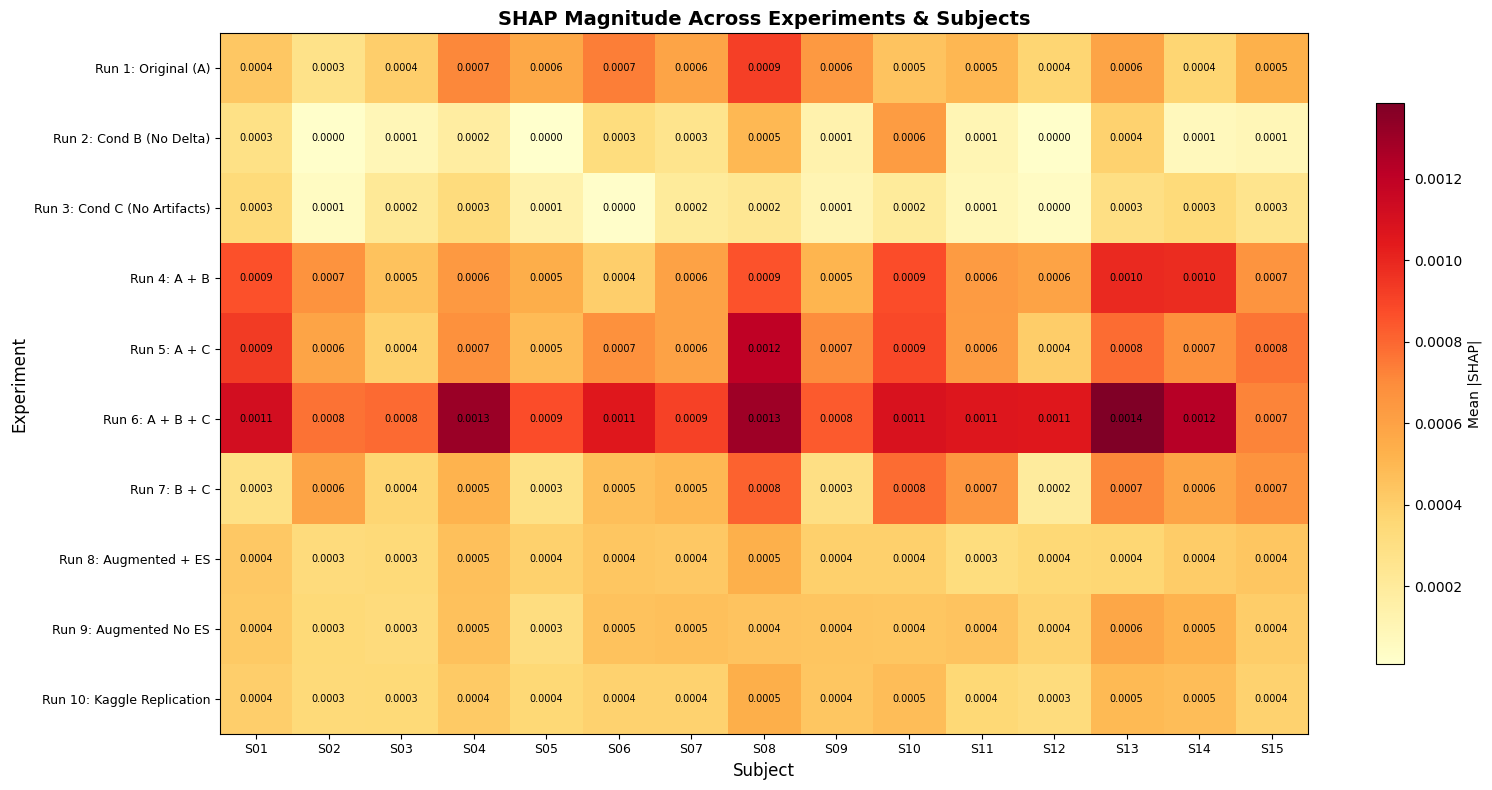

In [35]:
# ============================================================
# 7a. SHAP Magnitude Heatmap: Experiments × Subjects
# ============================================================
if shap_cache:
    runs_used = sorted(set(k[0] for k in shap_cache.keys()), key=lambda x: list(EXPERIMENTS.keys()).index(x))
    subs_used = sorted(set(k[1] for k in shap_cache.keys()))
    
    mag_matrix = np.full((len(runs_used), len(subs_used)), np.nan)
    for i, rk in enumerate(runs_used):
        for j, sid in enumerate(subs_used):
            if (rk, sid) in shap_cache:
                mag_matrix[i, j] = shap_cache[(rk, sid)]['mean_abs_shap']
    
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(mag_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|', shrink=0.8)
    ax.set_xticks(range(len(subs_used)))
    ax.set_xticklabels([f'S{s}' for s in subs_used], fontsize=9)
    ax.set_yticks(range(len(runs_used)))
    ax.set_yticklabels([EXPERIMENTS[r][0] for r in runs_used], fontsize=9)
    ax.set_xlabel('Subject', fontsize=12)
    ax.set_ylabel('Experiment', fontsize=12)
    ax.set_title('SHAP Magnitude Across Experiments & Subjects', fontsize=14, fontweight='bold')
    # Annotate cells
    for i in range(mag_matrix.shape[0]):
        for j in range(mag_matrix.shape[1]):
            if not np.isnan(mag_matrix[i, j]):
                ax.text(j, i, f'{mag_matrix[i,j]:.4f}', ha='center', va='center', fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'cross_exp_magnitude.png'), dpi=200)
    plt.show()
    plt.close()
else:
    print('No cached data — run the analysis loop first.')

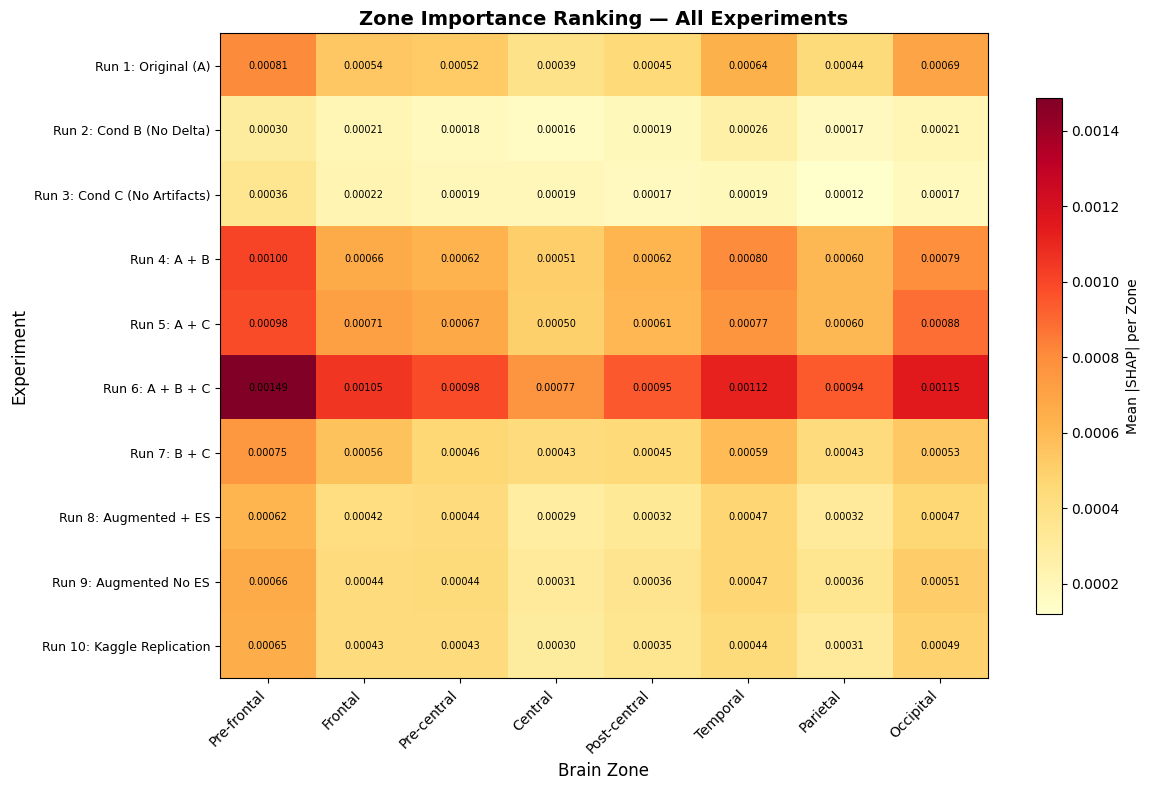

In [36]:
# ============================================================
# 7b. Zone Importance Ranking Across Experiments
# ============================================================
if shap_cache:
    zone_names = list(Zones.keys())
    zone_matrix = np.zeros((len(runs_used), len(zone_names)))
    
    for i, rk in enumerate(runs_used):
        zone_totals = {z: [] for z in zone_names}
        for sid in subs_used:
            if (rk, sid) in shap_cache:
                za = shap_cache[(rk, sid)]['zone_avgs']
                for z in zone_names:
                    if z in za:
                        zone_totals[z].append(za[z])
        for j, z in enumerate(zone_names):
            if zone_totals[z]:
                zone_matrix[i, j] = np.mean(zone_totals[z])
    
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(zone_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Mean |SHAP| per Zone', shrink=0.8)
    ax.set_xticks(range(len(zone_names)))
    ax.set_xticklabels(zone_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(runs_used)))
    ax.set_yticklabels([EXPERIMENTS[r][0] for r in runs_used], fontsize=9)
    ax.set_xlabel('Brain Zone', fontsize=12)
    ax.set_ylabel('Experiment', fontsize=12)
    ax.set_title('Zone Importance Ranking — All Experiments', fontsize=14, fontweight='bold')
    for i in range(zone_matrix.shape[0]):
        for j in range(zone_matrix.shape[1]):
            ax.text(j, i, f'{zone_matrix[i,j]:.5f}', ha='center', va='center', fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'cross_exp_zone_ranking.png'), dpi=200)
    plt.show()
    plt.close()

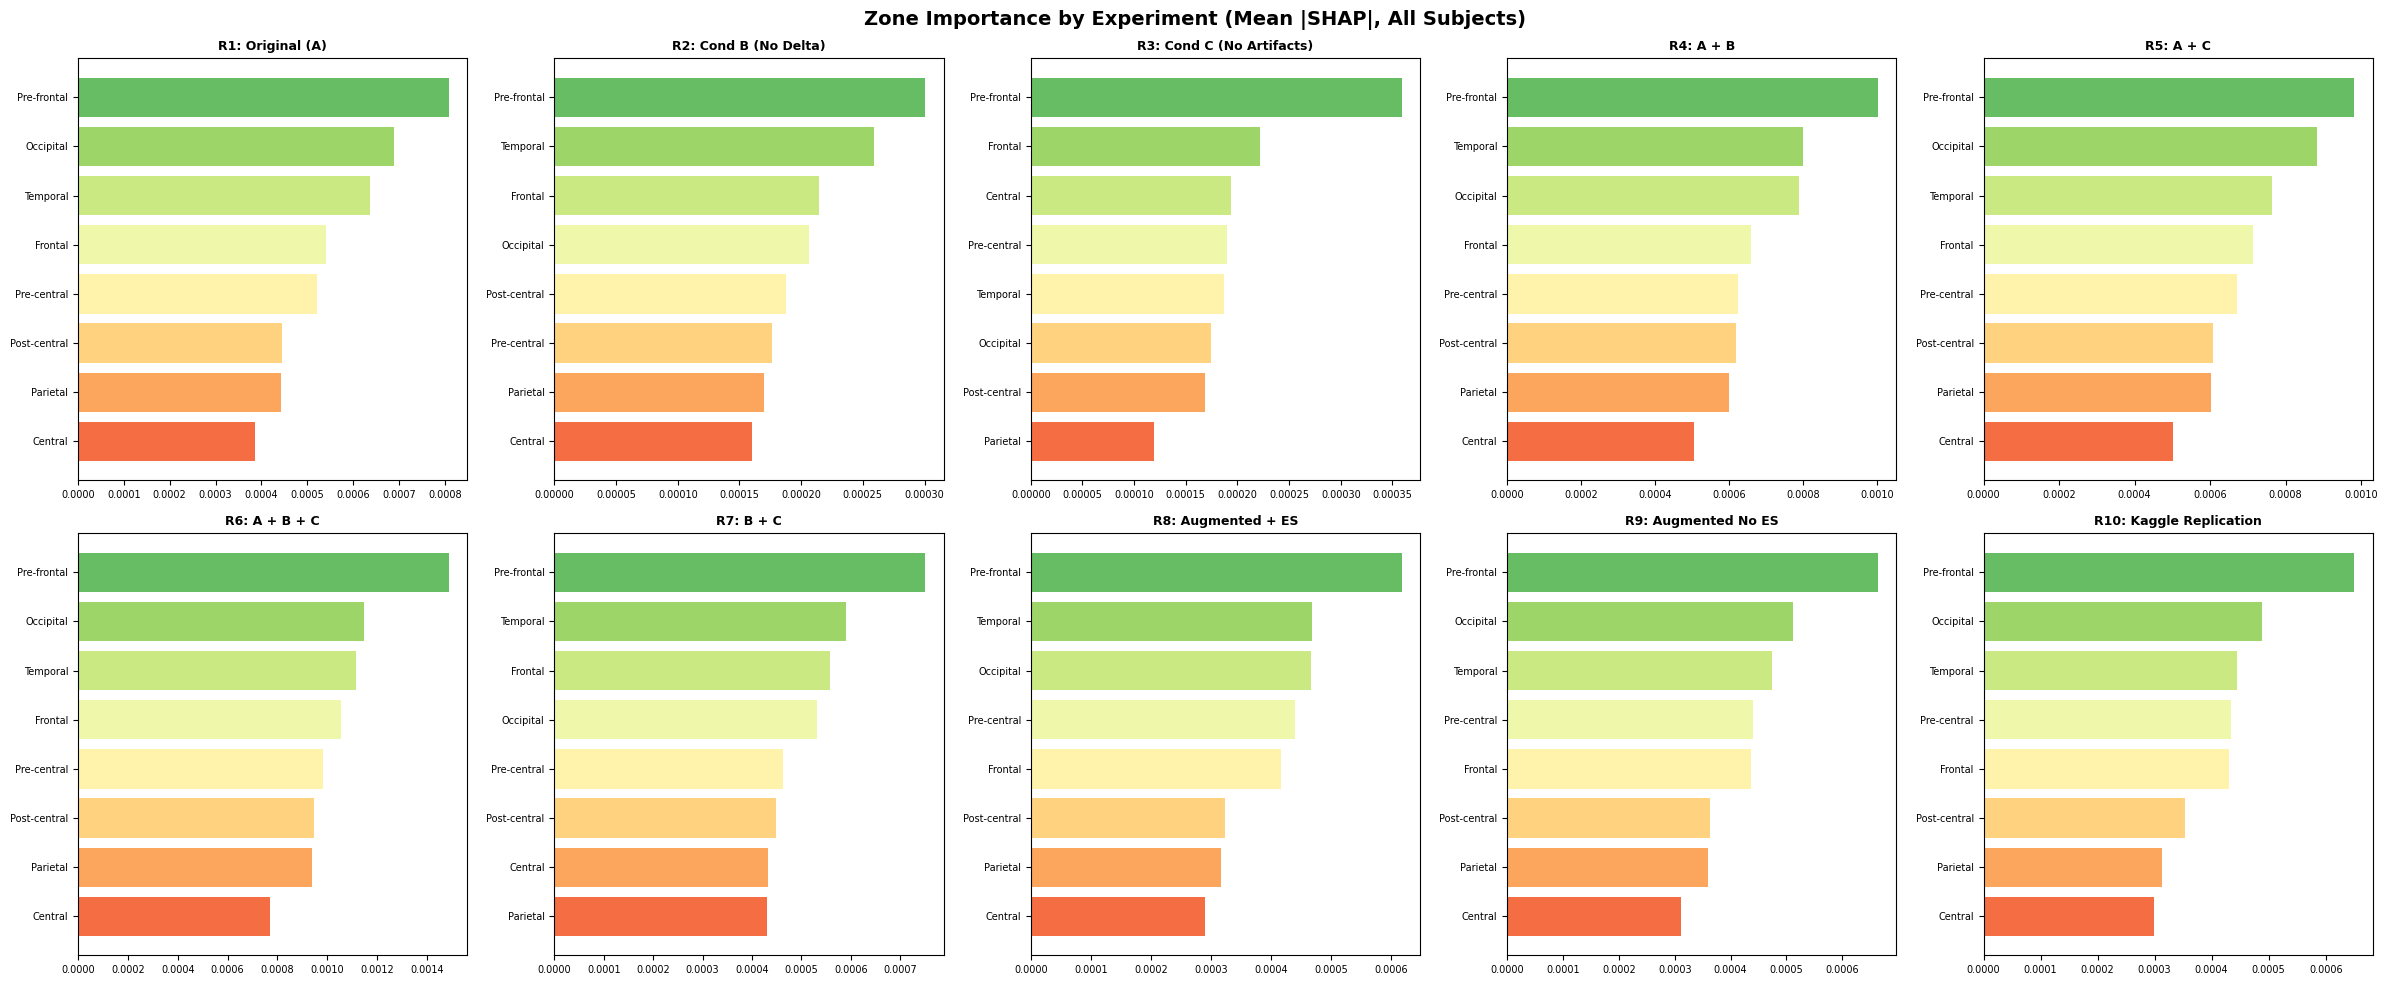

In [37]:
# ============================================================
# 7c. Mean Zone Importance Bar Chart (averaged across all subjects)
# ============================================================
if shap_cache:
    n_cols = 5
    n_rows = int(np.ceil(len(runs_used) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, rk in enumerate(runs_used):
        ax = axes[idx]
        zone_avg = {z: [] for z in zone_names}
        for sid in subs_used:
            if (rk, sid) in shap_cache:
                za = shap_cache[(rk, sid)]['zone_avgs']
                for z in zone_names:
                    if z in za:
                        zone_avg[z].append(za[z])

        z_means = {z: np.mean(v) if v else 0 for z, v in zone_avg.items()}
        sorted_z = sorted(z_means.items(), key=lambda x: x[1], reverse=True)
        zn = [z[0] for z in sorted_z]
        zv = [z[1] for z in sorted_z]

        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(zn)))
        ax.barh(range(len(zn)), zv[::-1], color=colors[::-1])
        ax.set_yticks(range(len(zn)))
        ax.set_yticklabels(zn[::-1], fontsize=7)
        ax.set_title(EXPERIMENTS[rk][0].replace('Run ', 'R'), fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

    # Hide unused axes
    for idx in range(len(runs_used), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Zone Importance by Experiment (Mean |SHAP|, All Subjects)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'zone_bars_all_experiments.png'), dpi=200)
    plt.show()
    plt.close()

## 8. Per-Subject Comparison Across Experiments

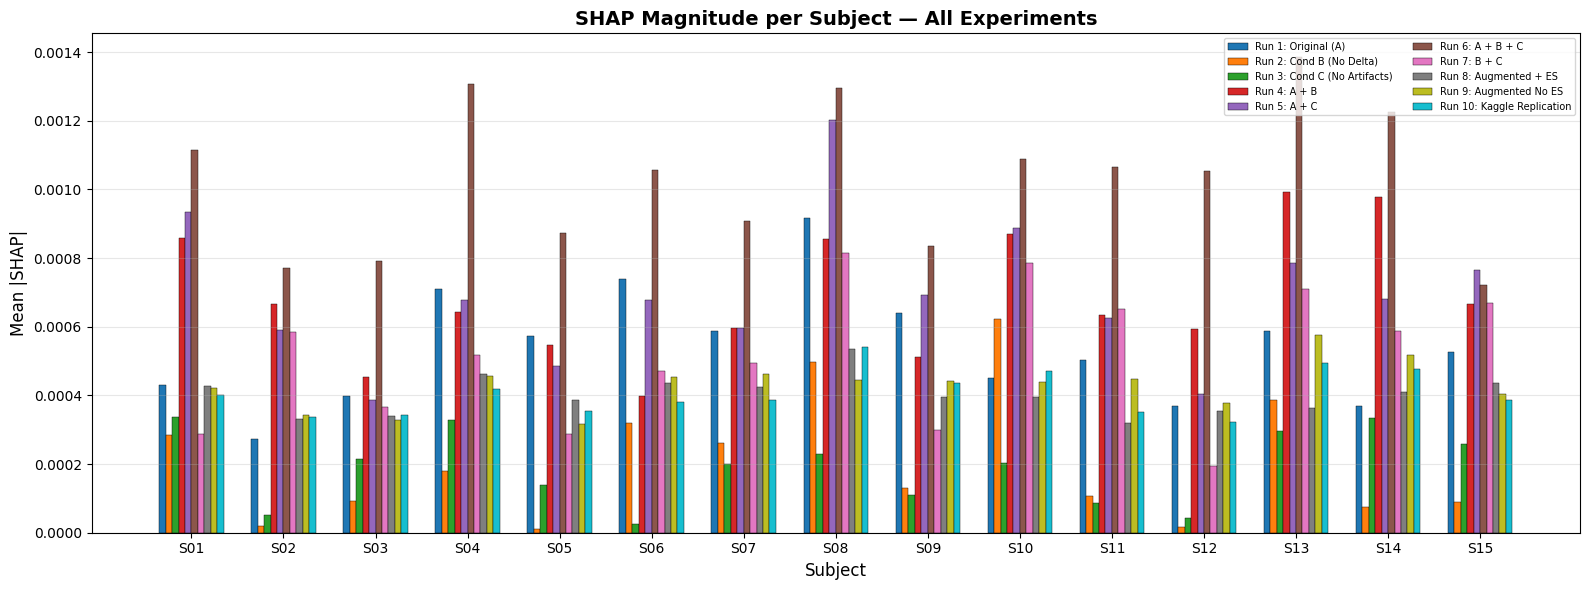

In [38]:
# ============================================================
# 8a. For each subject, compare SHAP magnitude across runs
# ============================================================
if shap_cache:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    x = np.arange(len(subs_used))
    n_runs = len(runs_used)
    width = 0.7 / n_runs
    colors = plt.cm.tab10(np.linspace(0, 1, n_runs))
    
    for i, rk in enumerate(runs_used):
        vals = []
        for sid in subs_used:
            if (rk, sid) in shap_cache:
                vals.append(shap_cache[(rk, sid)]['mean_abs_shap'])
            else:
                vals.append(0)
        offsets = x + (i - n_runs / 2 + 0.5) * width
        ax.bar(offsets, vals, width, label=EXPERIMENTS[rk][0], color=colors[i], edgecolor='black', linewidth=0.3)
    
    ax.set_xlabel('Subject', fontsize=12)
    ax.set_ylabel('Mean |SHAP|', fontsize=12)
    ax.set_title('SHAP Magnitude per Subject — All Experiments', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{s}' for s in subs_used])
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'per_subject_magnitude.png'), dpi=200)
    plt.show()
    plt.close()

## 9. Summary Statistics Table

## 10. Language Zone Focus Analysis

Compare SHAP magnitude across language-relevant (Broca's/Wernicke's area proxies),
motor-speech (articulatory cortex), and non-language brain zones.
Validates whether the model relies on neurolinguistically plausible regions.

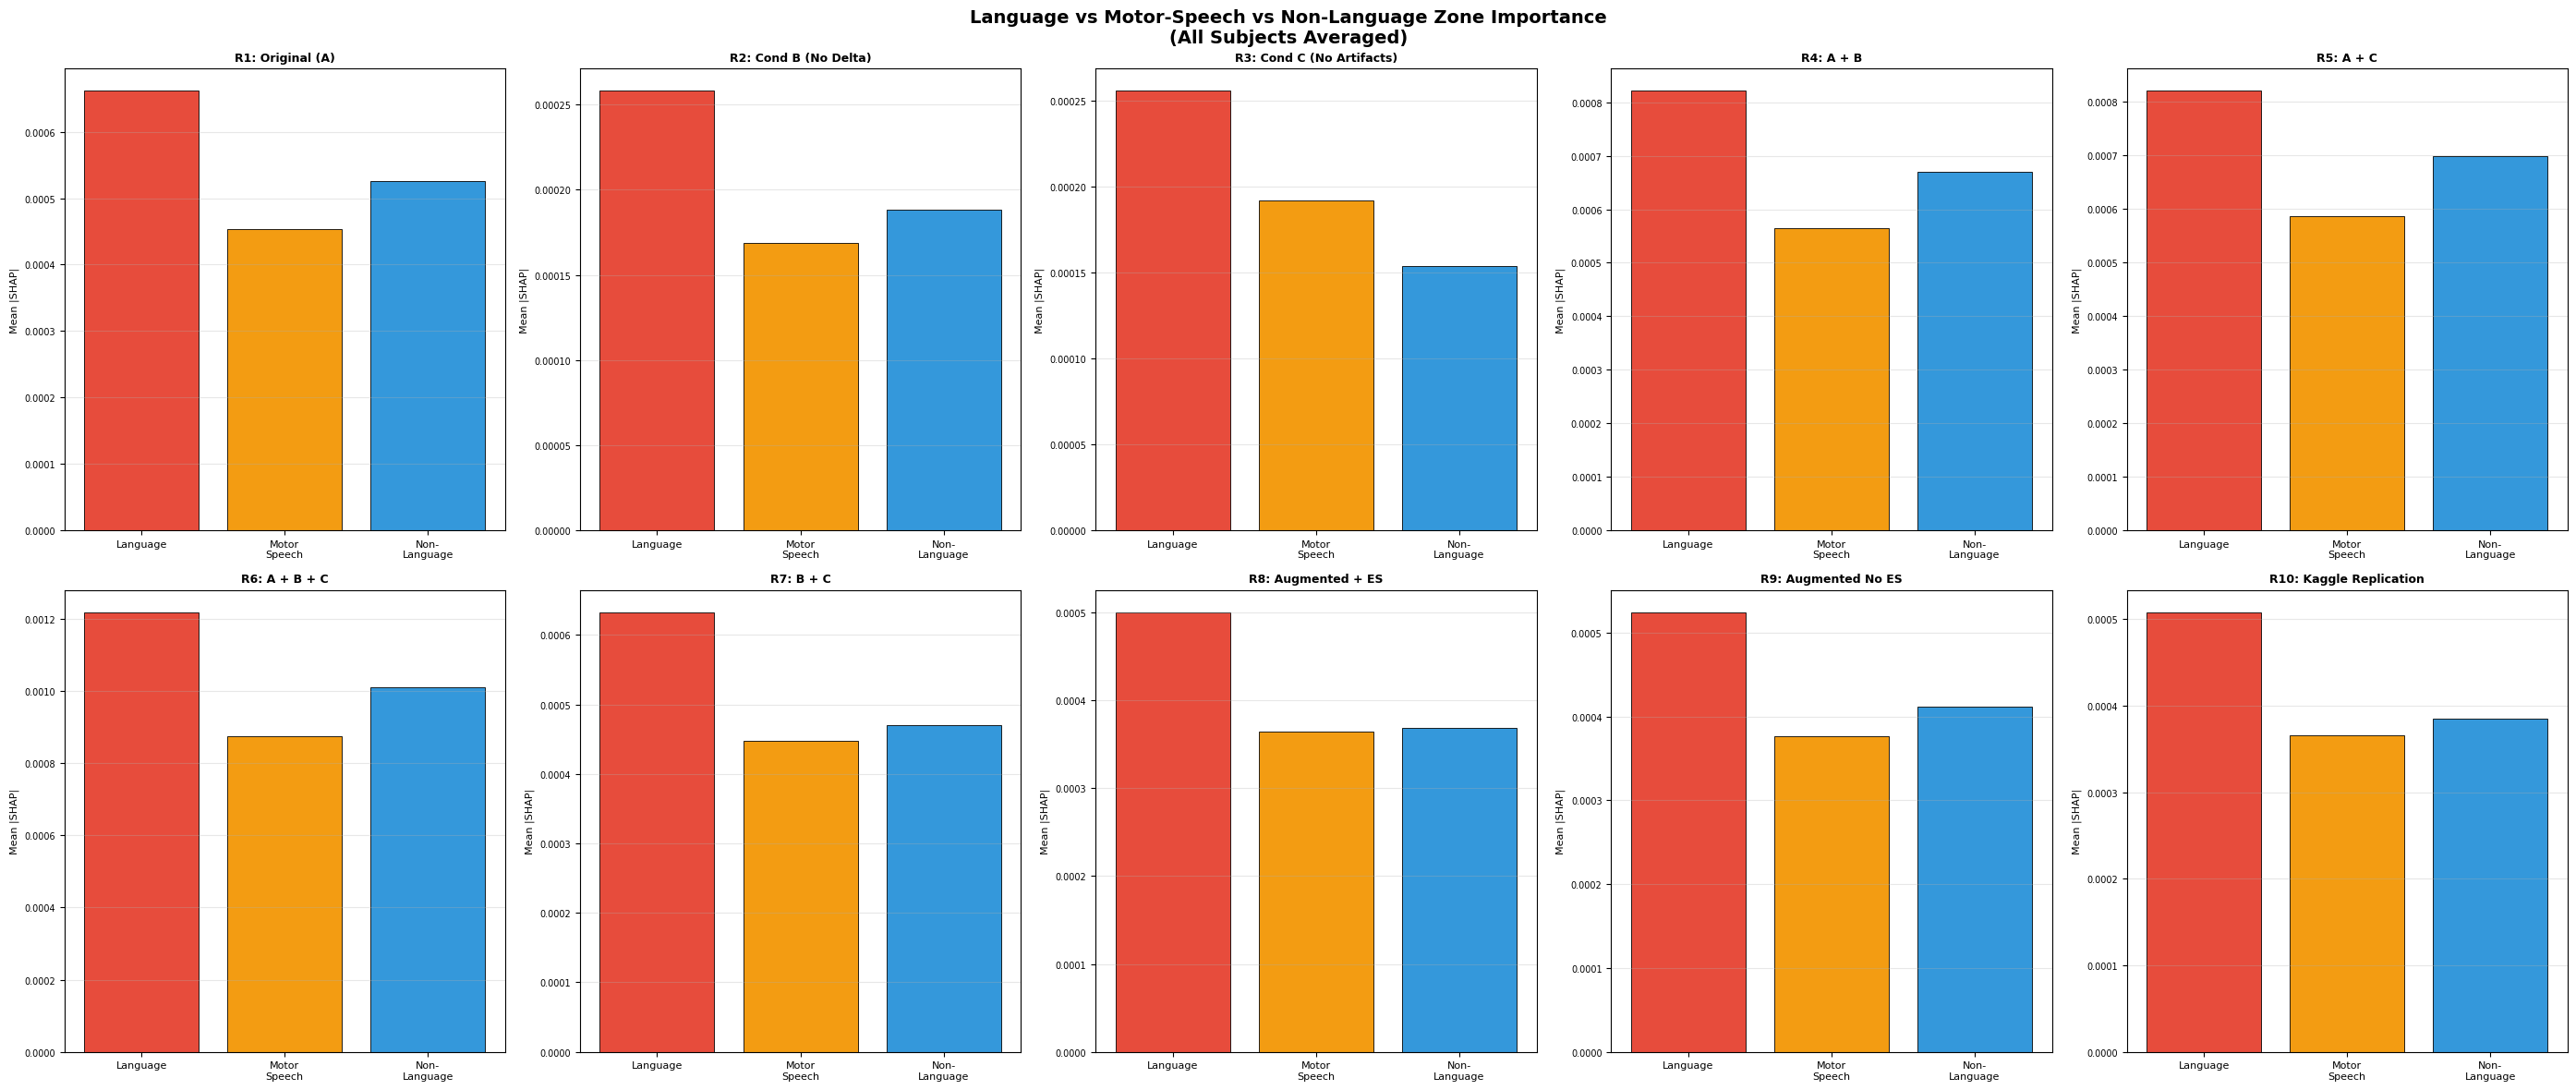

In [39]:
# ============================================================
# 10a. Per-experiment language zone comparison (averaged across subjects)
# ============================================================
if shap_cache:
    n_cols = 5
    n_rows = int(np.ceil(len(runs_used) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, rk in enumerate(runs_used):
        if idx >= len(axes):
            break
        ax = axes[idx]
        # Aggregate zone avgs across subjects
        agg_zones = {z: [] for z in Zones.keys()}
        for sid in subs_used:
            if (rk, sid) in shap_cache:
                za = shap_cache[(rk, sid)]['zone_avgs']
                for z in Zones.keys():
                    if z in za:
                        agg_zones[z].append(za[z])
        zone_means = {z: np.mean(v) if v else 0 for z, v in agg_zones.items()}

        groups = {
            'Language': np.mean([zone_means.get(z, 0) for z in ['Pre-frontal', 'Frontal', 'Temporal']]),
            'Motor\nSpeech': np.mean([zone_means.get(z, 0) for z in ['Pre-central', 'Central']]),
            'Non-\nLanguage': np.mean([zone_means.get(z, 0) for z in ['Parietal', 'Post-central', 'Occipital']]),
        }
        colors = ['#e74c3c', '#f39c12', '#3498db']
        ax.bar(range(3), list(groups.values()), color=colors, edgecolor='black', linewidth=0.6)
        ax.set_xticks(range(3))
        ax.set_xticklabels(list(groups.keys()), fontsize=8)
        ax.set_title(EXPERIMENTS[rk][0].replace('Run ', 'R'), fontsize=9, fontweight='bold')
        ax.set_ylabel('Mean |SHAP|', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', alpha=0.3)

    for idx in range(len(runs_used), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Language vs Motor-Speech vs Non-Language Zone Importance\n(All Subjects Averaged)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'language_zone_comparison.png'), dpi=200)
    plt.show()
    plt.close()

    # 10b. Single aggregated comparison across ALL experiments
    all_zone_means = {z: [] for z in Zones.keys()}
    for (rk, sid), cache in shap_cache.items():
        for z, v in cache['zone_avgs'].items():
            all_zone_means[z].append(v)
    global_zone = {z: np.mean(v) for z, v in all_zone_means.items() if v}
    plot_language_zone_comparison(
        global_zone,
        'Language Zone Focus — Global Average (All Experiments × All Subjects)',
        os.path.join(SHAP_OUTPUT, 'language_zone_global.png'))
else:
    print('No cached data.')

## 11. Class-Pair Discriminability Analysis

For the most frequently confused word pairs (from aggregated confusion matrices),
show spatial SHAP difference topomaps revealing what distinguishes each pair.
Particularly relevant for phonetically similar words (e.g., "hello" vs "help-me").

In [43]:
# ============================================================
# 11. Class-Pair Discriminability Topomaps
# ============================================================
if shap_cache:
    for rk in runs_used:
        exp_name = EXPERIMENTS[rk][0]
        out_dir = os.path.join(SHAP_OUTPUT, rk)
        os.makedirs(out_dir, exist_ok=True)

        # Aggregate confusion matrix and class topographies across subjects
        agg_confusion = np.zeros((5, 5), dtype=int)
        agg_topos = {ci: [] for ci in range(5)}
        for sid in subs_used:
            if (rk, sid) not in shap_cache:
                continue
            cache = shap_cache[(rk, sid)]
            agg_confusion += cache['confusion_counts']
            for ci, topo in cache['class_topos'].items():
                agg_topos[ci].append(topo)

        # Mean topography per class (averaged across subjects)
        mean_topos = {}
        for ci in range(5):
            if agg_topos[ci]:
                mean_topos[ci] = np.mean(agg_topos[ci], axis=0)

        # Find top confused pairs (off-diagonal)
        off_diag = []
        for i in range(5):
            for j in range(5):
                if i != j:
                    off_diag.append((agg_confusion[i, j], i, j))
        off_diag.sort(reverse=True)

        # Plot top 5 confused pairs
        n_show = min(5, len([x for x in off_diag if x[0] > 0]))
        for rank, (count, true_ci, pred_ci) in enumerate(off_diag[:n_show]):
            if count == 0 or true_ci not in mean_topos or pred_ci not in mean_topos:
                continue
            plot_class_pair_discriminability(
                mean_topos[true_ci], mean_topos[pred_ci],
                CLASSES[true_ci], CLASSES[pred_ci],
                f'{exp_name}\n"{CLASSES[true_ci]}" vs "{CLASSES[pred_ci]}" (N confused={count})',
                os.path.join(out_dir, f'discriminability_{CLASSES[true_ci]}_vs_{CLASSES[pred_ci]}.png'))

    # Also show all 10 unique class pairs for the best experiment (run1)
    best_rk = runs_used[0]
    agg_topos_best = {ci: [] for ci in range(5)}
    for sid in subs_used:
        if (best_rk, sid) in shap_cache:
            for ci, topo in shap_cache[(best_rk, sid)]['class_topos'].items():
                agg_topos_best[ci].append(topo)
    mean_topos_best = {ci: np.mean(v, axis=0) for ci, v in agg_topos_best.items() if v}

    if len(mean_topos_best) == 5:
        print(f'\nAll pairwise discriminability for {EXPERIMENTS[best_rk][0]}:')
        for ci_a, ci_b in combinations(range(5), 2):
            plot_class_pair_discriminability(
                mean_topos_best[ci_a], mean_topos_best[ci_b],
                CLASSES[ci_a], CLASSES[ci_b],
                f'{EXPERIMENTS[best_rk][0]}\n"{CLASSES[ci_a]}" vs "{CLASSES[ci_b]}"',
                os.path.join(SHAP_OUTPUT, best_rk,
                             f'pair_{CLASSES[ci_a]}_vs_{CLASSES[ci_b]}.png'))
else:
    print('No cached data.')

KeyError: 'confusion_counts'

## 12. Inter-Subject SHAP Correlation

Correlate channel-level SHAP topographies across subjects to identify
which subjects share similar imagined speech neural strategies vs which are outliers.
Computed per-class and globally (all classes averaged).

In [41]:
# ============================================================
# 12. Inter-Subject SHAP Correlation Matrices
# ============================================================
if shap_cache:
    for rk in runs_used:
        exp_name = EXPERIMENTS[rk][0]
        out_dir = os.path.join(SHAP_OUTPUT, rk)
        os.makedirs(out_dir, exist_ok=True)

        # Collect per-subject topographies
        sub_topos = {}  # sid -> (channels,) averaged across all classes
        sub_class_topos = {ci: {} for ci in range(5)}  # ci -> {sid -> (channels,)}
        for sid in subs_used:
            if (rk, sid) not in shap_cache:
                continue
            ct = shap_cache[(rk, sid)]['class_topos']
            if ct:
                # Global topo: mean across available classes
                sub_topos[sid] = np.mean([ct[ci] for ci in ct], axis=0)
                for ci in ct:
                    sub_class_topos[ci][sid] = ct[ci]

        valid_subs = sorted(sub_topos.keys())
        if len(valid_subs) < 3:
            continue

        # Global inter-subject correlation
        n = len(valid_subs)
        corr_global = np.full((n, n), np.nan)
        for i in range(n):
            for j in range(n):
                corr_global[i, j] = np.corrcoef(
                    sub_topos[valid_subs[i]], sub_topos[valid_subs[j]])[0, 1]

        plot_inter_subject_correlation(
            corr_global, valid_subs,
            f'{exp_name}\nInter-Subject SHAP Correlation (All Classes)',
            os.path.join(out_dir, 'inter_subject_corr_global.png'))

        # Per-class inter-subject correlation
        for ci in range(5):
            cn = CLASSES[ci]
            class_subs = sorted(sub_class_topos[ci].keys())
            if len(class_subs) < 3:
                continue
            nc = len(class_subs)
            corr_class = np.full((nc, nc), np.nan)
            for i in range(nc):
                for j in range(nc):
                    corr_class[i, j] = np.corrcoef(
                        sub_class_topos[ci][class_subs[i]],
                        sub_class_topos[ci][class_subs[j]])[0, 1]
            plot_inter_subject_correlation(
                corr_class, class_subs,
                f'{exp_name}\nInter-Subject Correlation: "{cn}"',
                os.path.join(out_dir, f'inter_subject_corr_{cn}.png'))

    print('Inter-subject correlation analysis complete.')
else:
    print('No cached data.')

KeyError: 'class_topos'

## 13. Per-Word Temporal SHAP Signatures

Compare how temporal importance profiles differ across the 5 imagined speech words.
Reveals whether different words have distinct temporal dynamics (onset, peak, duration)
across the 3.2-second trial window.

In [42]:
# ============================================================
# 13a. Per-experiment temporal signatures (averaged across subjects)
# ============================================================
if shap_cache:
    for rk in runs_used:
        exp_name = EXPERIMENTS[rk][0]
        out_dir = os.path.join(SHAP_OUTPUT, rk)
        os.makedirs(out_dir, exist_ok=True)

        # Aggregate temporal profiles across subjects
        agg_temporals = {ci: [] for ci in range(5)}
        for sid in subs_used:
            if (rk, sid) not in shap_cache:
                continue
            ct = shap_cache[(rk, sid)]['class_temporals']
            for ci, prof in ct.items():
                agg_temporals[ci].append(prof)

        profiles = {}
        for ci in range(5):
            if agg_temporals[ci]:
                profiles[CLASSES[ci]] = np.mean(agg_temporals[ci], axis=0)

        if profiles:
            plot_temporal_signature(
                profiles,
                f'{exp_name}\nPer-Word Temporal SHAP Signature (All Subjects)',
                os.path.join(out_dir, 'temporal_signature_all_subjects.png'))

    print('Per-experiment temporal signatures complete.')
else:
    print('No cached data.')

KeyError: 'class_temporals'

In [ ]:
# ============================================================
# 13b. Cross-experiment temporal signature comparison (global)
# ============================================================
if shap_cache:
    n_cols = 5
    n_rows = int(np.ceil(len(runs_used) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    colors = plt.cm.Set1(np.linspace(0, 1, 5))

    for idx, rk in enumerate(runs_used):
        if idx >= len(axes):
            break
        ax = axes[idx]
        agg_temporals = {ci: [] for ci in range(5)}
        for sid in subs_used:
            if (rk, sid) not in shap_cache:
                continue
            ct = shap_cache[(rk, sid)]['class_temporals']
            for ci, prof in ct.items():
                agg_temporals[ci].append(prof)

        for ci in range(5):
            if agg_temporals[ci]:
                mean_prof = np.mean(agg_temporals[ci], axis=0)
                time_ms = np.arange(len(mean_prof)) / SFREQ * 1000
                ax.plot(time_ms, mean_prof, label=CLASSES[ci], color=colors[ci], linewidth=1.2)

        ax.set_title(EXPERIMENTS[rk][0].replace('Run ', 'R'), fontsize=9, fontweight='bold')
        ax.set_xlabel('Time (ms)', fontsize=8)
        ax.set_ylabel('Mean |SHAP|', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6, loc='upper right')
        ax.grid(alpha=0.3)

    for idx in range(len(runs_used), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Per-Word Temporal SHAP Signatures — All Experiments',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'temporal_signatures_all_experiments.png'), dpi=200)
    plt.show()
    plt.close()
else:
    print('No cached data.')

## 14. Cross-Experiment Consistency & Stability

Analyzes how stable the top-K most important channels are across experiments,
and summarizes inter-subject correlation strength per experiment to identify
which training conditions produce more consistent neural representations.

In [ ]:
# ============================================================
# 14a. Top-K Channel Stability Across Experiments
# ============================================================
if shap_cache:
    TOP_K = 10

    # For each experiment, find top-K channels (by mean |SHAP| across subjects)
    exp_top_channels = {}
    for rk in runs_used:
        all_topos = []
        for sid in subs_used:
            if (rk, sid) in shap_cache:
                ct = shap_cache[(rk, sid)]['class_topos']
                if ct:
                    all_topos.append(np.mean([np.abs(ct[ci]) for ci in ct], axis=0))
        if all_topos:
            mean_topo = np.mean(all_topos, axis=0)
            top_idx = np.argsort(mean_topo)[-TOP_K:][::-1]
            exp_top_channels[rk] = set(top_idx)

    # Compute pairwise Jaccard similarity between top-K sets
    rk_list = [rk for rk in runs_used if rk in exp_top_channels]
    n_exp = len(rk_list)
    jaccard_matrix = np.zeros((n_exp, n_exp))
    for i in range(n_exp):
        for j in range(n_exp):
            a, b = exp_top_channels[rk_list[i]], exp_top_channels[rk_list[j]]
            jaccard_matrix[i, j] = len(a & b) / len(a | b)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(jaccard_matrix, cmap='YlGn', vmin=0, vmax=1, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Jaccard Similarity', shrink=0.8)
    ax.set_xticks(range(n_exp))
    ax.set_xticklabels([EXPERIMENTS[r][0].replace('Run ', 'R') for r in rk_list],
                       fontsize=8, rotation=45, ha='right')
    ax.set_yticks(range(n_exp))
    ax.set_yticklabels([EXPERIMENTS[r][0].replace('Run ', 'R') for r in rk_list], fontsize=8)
    for i in range(n_exp):
        for j in range(n_exp):
            ax.text(j, i, f'{jaccard_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
    ax.set_title(f'Top-{TOP_K} Channel Stability Across Experiments\n(Jaccard Similarity)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT, 'topk_channel_stability.png'), dpi=200)
    plt.show()
    plt.close()

    # Print the top-K channels per experiment
    print(f'\nTop-{TOP_K} Channels Per Experiment:')
    for rk in rk_list:
        top_idx = sorted(exp_top_channels[rk])
        ch_names = [Electrodes[i] for i in top_idx]
        print(f'  {EXPERIMENTS[rk][0]}: {", ".join(ch_names)}')
else:
    print('No cached data.')

In [ ]:
# ============================================================
# 14b. Inter-Subject Consistency Summary Across Experiments
# ============================================================
if shap_cache:
    exp_mean_corr = []
    exp_labels = []

    for rk in runs_used:
        sub_topos = {}
        for sid in subs_used:
            if (rk, sid) not in shap_cache:
                continue
            ct = shap_cache[(rk, sid)]['class_topos']
            if ct:
                sub_topos[sid] = np.mean([ct[ci] for ci in ct], axis=0)

        valid_subs = sorted(sub_topos.keys())
        if len(valid_subs) < 2:
            continue

        # Mean off-diagonal correlation
        corrs = []
        for i in range(len(valid_subs)):
            for j in range(i + 1, len(valid_subs)):
                r = np.corrcoef(sub_topos[valid_subs[i]], sub_topos[valid_subs[j]])[0, 1]
                corrs.append(r)
        exp_mean_corr.append(np.mean(corrs))
        exp_labels.append(EXPERIMENTS[rk][0])

    if exp_mean_corr:
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(exp_labels)))
        bars = ax.bar(range(len(exp_labels)), exp_mean_corr, color=colors,
                      edgecolor='black', linewidth=0.6)
        ax.set_xticks(range(len(exp_labels)))
        ax.set_xticklabels(exp_labels, fontsize=8, rotation=30, ha='right')
        ax.set_ylabel('Mean Inter-Subject Pearson r', fontsize=11)
        ax.set_title('Inter-Subject SHAP Consistency by Experiment\n(Higher = More Consistent Neural Strategies)',
                     fontsize=13, fontweight='bold')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.grid(axis='y', alpha=0.3)

        # Annotate bars
        for i, v in enumerate(exp_mean_corr):
            ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.savefig(os.path.join(SHAP_OUTPUT, 'inter_subject_consistency_summary.png'), dpi=200)
        plt.show()
        plt.close()
else:
    print('No cached data.')

In [ ]:
# ============================================================
# Build a summary DataFrame of SHAP statistics per experiment
# ============================================================
if shap_cache:
    rows = []
    for rk in runs_used:
        mags = [shap_cache[(rk, s)]['mean_abs_shap'] for s in subs_used if (rk, s) in shap_cache]
        
        # Top zone per experiment
        zone_agg = {z: [] for z in zone_names}
        for sid in subs_used:
            if (rk, sid) in shap_cache:
                za = shap_cache[(rk, sid)]['zone_avgs']
                for z in zone_names:
                    if z in za:
                        zone_agg[z].append(za[z])
        zone_means = {z: np.mean(v) for z, v in zone_agg.items() if v}
        top_zone = max(zone_means, key=zone_means.get) if zone_means else 'N/A'
        
        rows.append({
            'Experiment': EXPERIMENTS[rk][0],
            'Mean |SHAP|': np.mean(mags) if mags else np.nan,
            'Std |SHAP|': np.std(mags) if mags else np.nan,
            'Min |SHAP|': np.min(mags) if mags else np.nan,
            'Max |SHAP|': np.max(mags) if mags else np.nan,
            'Top Zone': top_zone,
            'N Subjects': len(mags),
        })
    
    df_summary = pd.DataFrame(rows)
    print(df_summary.to_string(index=False, float_format='%.6f'))
    df_summary.to_csv(os.path.join(SHAP_OUTPUT, 'shap_summary.csv'), index=False)
    print(f'\nSaved to {SHAP_OUTPUT}/shap_summary.csv')
else:
    print('No cached data.')